In [1]:
import sys 
import os 
sys.path.append('/volume_4/research/seongbong/flywire/geosmin_project_version_update/code')
from analysis_of_simulation_result import * 
from fitting import *
from plot_of_experiment_data import std_err
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7
colors_labial = ['#26ac39','#f39900']
colors_tarsal = ['#13739E','#952B7E']

# Load experiment Data

In [2]:
from pathlib import Path
ROOT = Path("/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure4/PER_fitting_final/data/Experiment_data_final")

DATASETS = {
    "tarsal_all": {
        "path": ROOT / "tarsal_PER.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "tarsal_TPN1": {
        "path": ROOT / "atGRN_Kir2.1.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "tarsal_atGRN": {
        "path": ROOT / "Gr5a_Kir2.1.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "labial_all": {
        "path": ROOT / "labial_PER.xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "labial_L1L2": {
        "path": ROOT / "Ir56b_Kir2.1(L1+L2).xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
    "labial_L3": {
        "path": ROOT / "Gr64f-Ir56b_Kir2.1(L3).xlsx",
        "sugar_sheet": "sugar",
        "geosmin_sheet": "sugar+geosmin",
    },
}

experiment_data = {
    name: load_per_pair(
        excel_path=info["path"],
        sugar_sheet=info["sugar_sheet"],
        geosmin_sheet=info["geosmin_sheet"],
    )
    for name, info in DATASETS.items()
}



# Load simulation data

In [3]:
from scipy.interpolate import RegularGridInterpolator
at_vals = np.arange(0, 201, 20)   # [0,20,...,200] → 11개
tp_vals = np.arange(0, 201, 20)   # 11개

Z_sim_tarsal = np.array(pd.read_parquet('data/simulation_data_final/tarsal/tarsal_sugar.parquet'))
Z_sim_geo_tarsal = np.array(pd.read_parquet('data/simulation_data_final/tarsal/tarsal_sugar_geosmin_170Hz.parquet'))


Z_sim_labial = np.array(pd.read_parquet('data/simulation_data_final/labellar/labial_sugar.parquet'))
Z_sim_geo_labial = np.array(pd.read_parquet('data/simulation_data_final/labellar/labial_sugar_geosmin_170Hz.parquet'))


interp_func_labial = make_interpolator(Z_sim_labial, at_vals)
interp_func_geo_labial = make_interpolator(Z_sim_geo_labial, at_vals)

interp_func_tarsal = make_interpolator(Z_sim_tarsal, at_vals)
interp_func_geo_tarsal = make_interpolator(Z_sim_geo_tarsal, at_vals)

# Load prefitted parameters

In [4]:
params_opt_tarsal = pickle.load(open('data_wo_constraint/tarsal/result_av1a1_170.pkl','rb'))
params_opt_labial = pickle.load(open('data_wo_constraint/labial/result_av1a1_170.pkl','rb'))

V_l1l2,K_l1l2,n_l1l2,V_l3,K_l3,n_l3,k_act_L,r0_L,h_L = params_opt_labial.x
V_at,K_at,n_at,V_tp,K_tp,n_tp,k_act_T,r0_T,h_T = params_opt_tarsal.x

print("Labial 100mM",V_l1l2 * (100**n_l1l2) / (K_l1l2**n_l1l2 + 100**n_l1l2),V_l3 * (100**n_l3) / (K_l3**n_l3 + 100**n_l3))
print("Tarsal 100mM",V_at * (100**n_at) / (K_at**n_at + 100**n_at),V_tp * (100**n_tp) / (K_at**n_tp + 100**n_tp))




Labial 100mM 25.69432050525632 23.51899623520979
Tarsal 100mM 88.36107140283528 82.5445755195146


# Plot

In [5]:
# hill_params_atgrn = (V_at, K_at, n_at)
# hill_params_tpn1 = (V_tp, K_tp, n_tp)
# activation_params = (k_act_T, r0_T, h_T)

# FIGURES = {
#     "both": {
#         "experiment": experiment_data["tarsal_all"],
#         "filename": "figures/atGRN_TPN1.svg",
#     },
#     "atGRN": {
#         "experiment": experiment_data["tarsal_atGRN"],
#         "filename": "figures/atGRN.svg",
#     },
#     "TPN1": {
#         "experiment": experiment_data["tarsal_TPN1"],
#         "filename": "figures/TPN1.svg",
#     },
# }

# for mode, info in FIGURES.items():
#     fig, ax = plt.subplots(1, 1, figsize=(2, 2))

#     plot_tarsal_condition(
#         ax=ax,
#         mode=mode,
#         interp_sugar=interp_func_tarsal,
#         interp_geosmin=interp_func_geo_tarsal,
#         experiment=info["experiment"],
#         hill_params_atgrn=hill_params_atgrn,
#         hill_params_tpn1=hill_params_tpn1,
#         activation_params=activation_params,
#         colors=colors_tarsal,
#     )

#     fig.savefig(info["filename"], bbox_inches="tight")

In [8]:
pwd

'/volume_4/research/seongbong/flywire/geosmin_project_version_update/figure4/PER_fitting_final'

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


첫 번째 그림의 x축 범위: (6.237348354824193, 1273.5030810166616)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


첫 번째 그림의 x축 범위: (6.237348354824193, 1273.5030810166616)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


첫 번째 그림의 x축 범위: (6.237348354824193, 1273.5030810166616)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

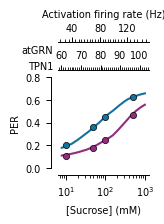

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

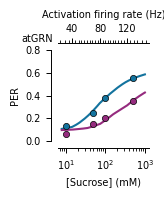

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

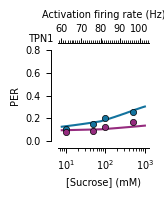

In [10]:
hill_params_atgrn = (V_at, K_at, n_at)
hill_params_tpn1 = (V_tp, K_tp, n_tp)
activation_params_tarsal = (k_act_T, r0_T, h_T)
# Tarsal
TARSAL_FIGURES = {
    "both": {
        "experiment": experiment_data["tarsal_all"],
        "filename": "figures_method/atGRN_TPN1.svg",
    },
    "first": {
        "experiment": experiment_data["tarsal_atGRN"],
        "filename": "figures_method/atGRN.svg",
    },
    "second": {
        "experiment": experiment_data["tarsal_TPN1"],
        "filename": "figures_method/TPN1.svg",
    },
}

for mode, info in TARSAL_FIGURES.items():
    fig, ax = plt.subplots(1, 1, figsize=(1.18, 1.18))

    plot_condition(
        ax=ax,
        mode=mode,
        interp_sugar=interp_func_tarsal,
        interp_geosmin=interp_func_geo_tarsal,
        experiment=info["experiment"],
        hill_params_first=hill_params_atgrn,
        hill_params_second=hill_params_tpn1,
        activation_params=activation_params_tarsal,
        labels=("atGRN", "TPN1"),
        colors=colors_tarsal,
    )
    xlim = ax.get_xlim()
    print("첫 번째 그림의 x축 범위:", xlim)
    fig.savefig(info["filename"])

In [15]:
hill_params_atgrn = (V_at, K_at, n_at)
hill_params_tpn1 = (V_tp, K_tp, n_tp)
activation_params_tarsal = (k_act_T, r0_T, h_T)


# Tarsal
TARSAL_FIGURES = {
    "both": {
        "experiment": experiment_data["tarsal_all"],
        "filename": "figures_method/atGRN_TPN1.svg",
    },
    "first": {
        "experiment": experiment_data["tarsal_atGRN"],
        "filename": "figures_method/atGRN.svg",
    },
    "second": {
        "experiment": experiment_data["tarsal_TPN1"],
        "filename": "figures_method/TPN1.svg",
    },
}


# --------------------------------------------------
# Figure 및 axes 크기 설정
# 단위: inch
# --------------------------------------------------

fig_width = 1.18

fig_height_single = 1.18
fig_height_both = 1.45

# 기존 plt.subplots()의 기본 axes 배치를 기준으로 계산
left_inch = fig_width * 0.125
bottom_inch = fig_height_single * 0.11

axes_width_inch = fig_width * 0.775
axes_height_inch = fig_height_single * 0.77


for mode, info in TARSAL_FIGURES.items():

    # both일 때만 위쪽 공간을 추가
    if mode == "both":
        fig_height = fig_height_both
    else:
        fig_height = fig_height_single

    fig = plt.figure(figsize=(fig_width, fig_height))

    # inch 단위로 고정한 axes 크기를
    # figure 좌표(0~1)로 변환
    ax_rect = [
        left_inch / fig_width,
        bottom_inch / fig_height,
        axes_width_inch / fig_width,
        axes_height_inch / fig_height,
    ]

    ax = fig.add_axes(ax_rect)

    plot_condition(
        ax=ax,
        mode=mode,
        interp_sugar=interp_func_tarsal,
        interp_geosmin=interp_func_geo_tarsal,
        experiment=info["experiment"],
        hill_params_first=hill_params_atgrn,
        hill_params_second=hill_params_tpn1,
        activation_params=activation_params_tarsal,
        labels=("atGRN", "TPN1"),
        colors=colors_tarsal,
    )

    print(
        f"{mode}: "
        f"figure size = {fig.get_size_inches()}, "
        f"xlim = {ax.get_xlim()}"
    )

    fig.savefig(
        info["filename"],
        bbox_inches=None,
    )

    plt.close(fig)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


both: figure size = [1.18 1.45], xlim = (6.237348354824193, 1273.5030810166616)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


first: figure size = [1.18 1.18], xlim = (6.237348354824193, 1273.5030810166616)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


second: figure size = [1.18 1.18], xlim = (6.237348354824193, 1273.5030810166616)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

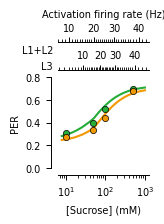

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

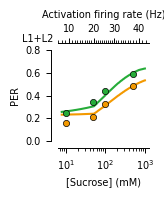

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

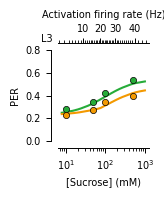

In [7]:
hill_params_l1l2 = (V_l1l2, K_l1l2, n_l1l2)
hill_params_l3 = (V_l3, K_l3, n_l3)
activation_params_labial = (k_act_L, r0_L, h_L)

LABIAL_FIGURES = {
    "both": {
        "experiment": experiment_data["labial_all"],
        "filename": "figures/L1L2_L3.svg",
    },
    "first": {
        "experiment": experiment_data["labial_L1L2"],
        "filename": "figures/L1L2.svg",
    },
    "second": {
        "experiment": experiment_data["labial_L3"],
        "filename": "figures/L3.svg",
    },
}

labial_tick_config = {
    "both": {
        "first": {
            "major_ticks": np.arange(0, 141, 10),
            "minor_ticks": np.arange(0, 141, 1),
        },
        "second": {
            "major_ticks": np.arange(0, 141, 10),
            "minor_ticks": np.arange(0, 141, 1),
        },
    },
    "first": {
        "major_ticks": np.arange(0, 141, 10),
        "minor_ticks": np.arange(0, 141, 1),
    },
    "second": {
        "major_ticks": np.arange(0, 141, 10),
        "minor_ticks": np.arange(0, 141, 1),
    },
}

for mode, info in LABIAL_FIGURES.items():
    fig, ax = plt.subplots(1, 1, figsize=(1.18, 1.18))

    plot_condition(
        ax=ax,
        mode=mode,
        interp_sugar=interp_func_labial,
        interp_geosmin=interp_func_geo_labial,
        experiment=info["experiment"],
        hill_params_first=hill_params_l1l2,
        hill_params_second=hill_params_l3,
        activation_params=activation_params_labial,
        labels=("L1+L2", "L3"),
        colors=colors_labial,
        axis_tick_config=labial_tick_config,
    )

    fig.savefig(info["filename"])